In [1]:
import pandas as pd
df = pd.read_csv("Maternal Health Risk Data Set.csv")
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df['RiskLevel'].value_counts())

(1014, 7)
   Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
0   25         130           80  15.0      98.0         86  high risk
1   35         140           90  13.0      98.0         70  high risk
2   29          90           70   8.0     100.0         80  high risk
3   30         140           85   7.0      98.0         70  high risk
4   35         120           60   6.1      98.0         76   low risk
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB
None
Age            0
S

In [2]:
# Rename columns
df.columns = df.columns.str.strip().str.replace(" ", "_")
# Encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Risk'] = le.fit_transform(df['RiskLevel'])
# Separate features and target
X = df.drop(columns=['RiskLevel', 'Risk'])
y = df['Risk']
# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
#Splitting Data into Training and Testing Sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
#Generating Classification Report for RandomForest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95        55
           1       0.89      0.80      0.84        81
           2       0.76      0.87      0.81        67

    accuracy                           0.86       203
   macro avg       0.87      0.87      0.87       203
weighted avg       0.87      0.86      0.86       203



In [5]:
!pip install xgboost

In [6]:
#Generating Classification Report for Ensemble Model
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
model_rf = RandomForestClassifier()
model_xgb = XGBClassifier()
model_svm = SVC(probability=True) # to ensure for soft voting
ensemble = VotingClassifier(
estimators=[('rf', model_rf), ('xgb', model_xgb), ('svm', model_svm)],
voting='soft'
)
ensemble.fit(X_train, y_train)
y_pred_ensemble = ensemble.predict(X_test)
print(classification_report(y_test, y_pred_ensemble))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95        55
           1       0.92      0.85      0.88        81
           2       0.80      0.88      0.84        67

    accuracy                           0.89       203
   macro avg       0.89      0.89      0.89       203
weighted avg       0.89      0.89      0.89       203



In [7]:
# 1. Confirm model object exists
print(model_rf) # should show RandomForestClassifier(...)
# 2. Confirm model is fitted
import inspect
print(hasattr(model_rf, "estimators_")) # should be True after fit
# OR try:
try:
    getattr(model_rf, "estimators_")
    print("Model fitted (estimators_ present).")
except AttributeError:
    print("Model NOT fitted or not a tree ensemble.")

RandomForestClassifier()
False
Model NOT fitted or not a tree ensemble.


In [8]:
!pip install shap

estimators_ present: True


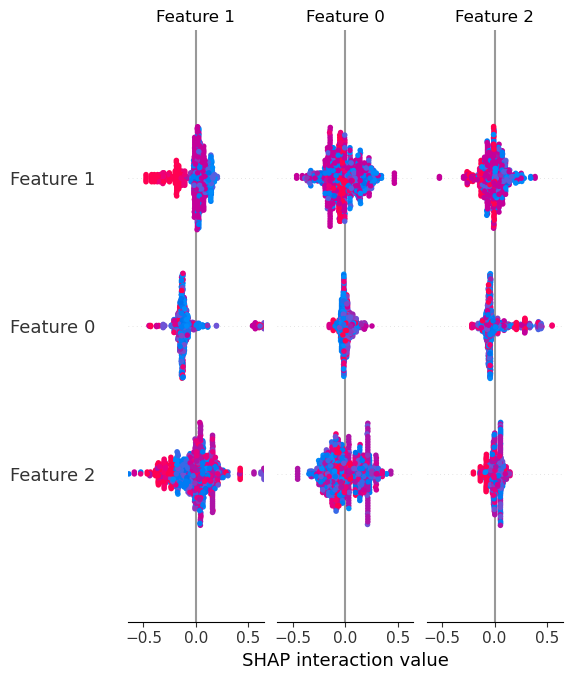

In [9]:
#Generating SHAP Plots
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
# (Recreate / ensure X_train, y_train are available as numpy arrays or DataFrame)
# Example: X_train, X_test, y_train, y_test already created earlier
# 1) Create and fit the RF (or fit the existing model_rf)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
# 2) Verify
print("estimators_ present:", hasattr(model_rf, "estimators_"))
# 3) Use TreeExplainer (works for tree models)
import shap
explainer = shap.TreeExplainer(model_rf)
# For multiclass RandomForestClassifier, shap_values will be a list (one array per class)
shap_values = explainer.shap_values(X_train)
# 4) Summary plot (if X_train is numpy, pass feature names separately)
# If X_train is DataFrame, you can pass it directly
import matplotlib.pyplot as plt
shap.summary_plot(shap_values, X_train) # will plot per-class summaries for multiclass
plt.show()

In [10]:
!pip install lime

In [11]:
#Generating LIME Explainations
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import HTML, display

explainer = LimeTabularExplainer(
    training_data=X_train,
    feature_names=X.columns,
    class_names=['Low', 'Medium', 'High'],
    mode='classification'
)

exp = explainer.explain_instance(
    X_test[0],
    ensemble.predict_proba,
    num_features=6
)

display(HTML(exp.as_html()))

In [12]:
#Cross-Validation Performance of the Ensemble Model
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(ensemble, X_scaled, y, cv=cv, scoring='f1_macro')
print("Cross Validation Performance of the Ensemble Model:")
print("Mean F1-score:", scores.mean())
print("Std Dev:", scores.std())

Cross Validation Performance of the Ensemble Model:
Mean F1-score: 0.8678241960228961
Std Dev: 0.0246109448219758


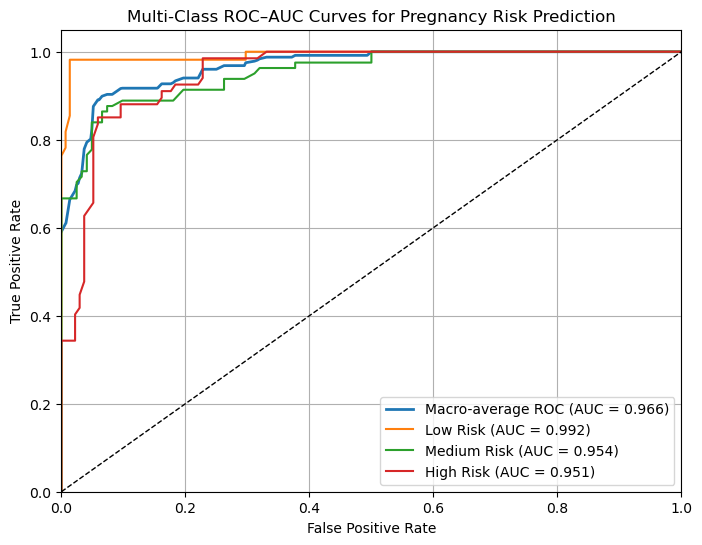

In [13]:
#ROC–AUC (Multi-Class) Curves for Pregnancy Risk Prediction
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
# Number of classes
n_classes = 3
class_names = ['Low Risk', 'Medium Risk', 'High Risk']
# Binarize the output labels
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
# Predict probabilities
y_score = ensemble.predict_proba(X_test)
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Compute macro-average ROC curve
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(
fpr["macro"], tpr["macro"],
label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.3f})',
linewidth=2
)
for i in range(n_classes):
    plt.plot(
        fpr[i], tpr[i],
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})'
    )
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC–AUC Curves for Pregnancy Risk Prediction')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Brier Score (Low Risk): 0.0246
Brier Score (Medium Risk): 0.0872
Brier Score (High Risk): 0.0921


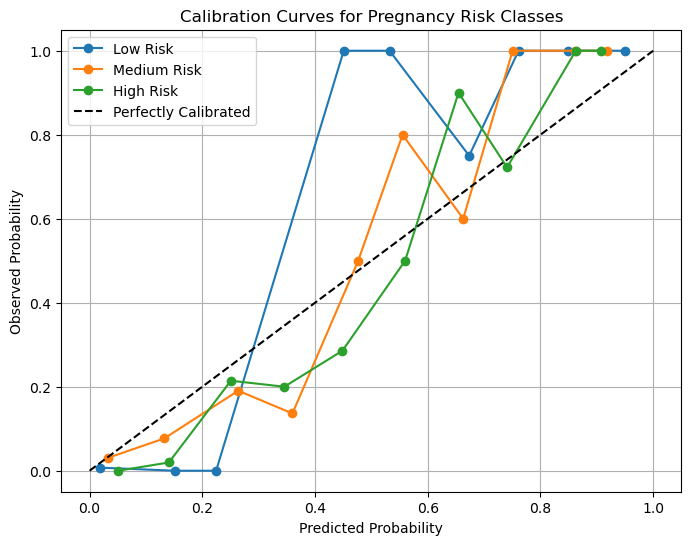

In [14]:
#Calibration Curves for Probability Class Prediction
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    prob_true, prob_pred = calibration_curve(
        (y_test == i).astype(int),
        y_score[:, i],
        n_bins=10,
        strategy='uniform'
    )

    plt.plot(prob_pred, prob_true, marker='o', label=class_names[i])

    brier = brier_score_loss((y_test == i).astype(int), y_score[:, i])
    print(f'Brier Score ({class_names[i]}): {brier:.4f}')

# Perfect calibration line
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')

plt.xlabel('Predicted Probability')
plt.ylabel('Observed Probability')
plt.title('Calibration Curves for Pregnancy Risk Classes')
plt.legend()
plt.grid(True)
plt.show()

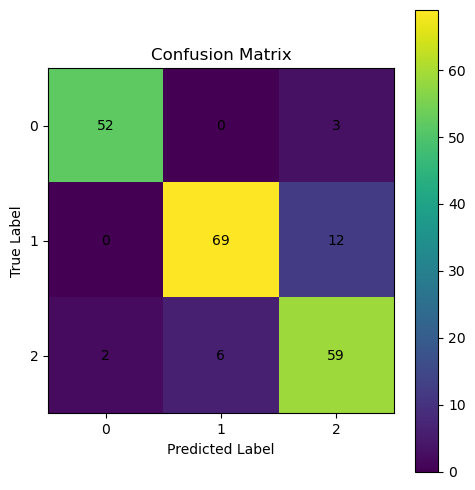

In [15]:
#Confusion Matrix
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
y_pred = ensemble.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = np.unique(y_test)
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Add values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()